# Setup and Initialization

## Import Libraries

In [171]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [172]:
np.set_printoptions(precision=2, suppress=True)
pd.options.display.float_format = '{:.2f}'.format

## Data Loading

In [173]:
KAGGLE_PATH = Path("/kaggle/input/competitions/mlp-term-1-2026-kaggle-assignment-1")
LOCAL_PATH = Path("./data")

DATA_DIR = KAGGLE_PATH if KAGGLE_PATH.exists() else LOCAL_PATH

print("DATA_DIR set to:")
print(DATA_DIR)

DATA_DIR set to:
data


In [174]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("Train rows:", train.shape[0])
print("Train columns:", train.shape[1])

print("Test rows:", test.shape[0])
print("Test columns:", test.shape[1])

Train rows: 10000
Train columns: 17
Test rows: 1500
Test columns: 17


In [175]:
col_mid = train.shape[1] // 2

print("Train data preview - Part 1 (First half of columns):")
display(train.iloc[:, :col_mid].head())

print("Train data preview - Part 2 (Remaining columns):")
display(train.iloc[:, col_mid:].head())

Train data preview - Part 1 (First half of columns):


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID
0,0,2023-06-28 17:31:46,2023-06-28 18:22:12,1.00,1.50,1.00,N,212
1,0,2023-06-29 19:15:55,2023-06-29 19:07:31,1.00,3.80,1.00,N,6
2,1,2023-06-30 18:28:50,2023-06-30 18:01:19,2.00,1.89,1.00,N,35
3,1,2023-06-30 22:57:37,2023-06-30 22:55:34,1.00,1.10,1.00,N,46
4,1,2023-06-28 18:39:16,2023-06-28 17:31:29,2.00,2.84,1.00,N,213


Train data preview - Part 2 (Remaining columns):


,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,237,Credit Card,5.00,6.53,0.00,1.00,24.80,2.50,0.00
1,163,Credit Card,5.00,9.19,0.00,1.00,31.55,2.50,0.00
2,81,Credit Card,2.50,6.79,0.00,1.00,24.84,2.50,0.00
3,99,Credit Card,1.00,3.70,0.00,1.00,13.45,2.50,0.00
4,114,Credit Card,2.50,7.84,0.00,1.00,29.88,2.50,0.00


### Column Data Types

In [176]:
print("Displaying basic info for train dataset:")
train.info()

Displaying basic info for train dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   tpep_pickup_datetime   10000 non-null  object 
 2   tpep_dropoff_datetime  10000 non-null  object 
 3   passenger_count        9634 non-null   float64
 4   trip_distance          10000 non-null  float64
 5   RatecodeID             9634 non-null   float64
 6   store_and_fwd_flag     9634 non-null   object 
 7   PULocationID           10000 non-null  int64  
 8   DOLocationID           10000 non-null  int64  
 9   payment_type           10000 non-null  object 
 10  extra                  10000 non-null  float64
 11  tip_amount             10000 non-null  float64
 12  tolls_amount           10000 non-null  float64
 13  improvement_surcharge  10000 non-null  float64
 14  total_amount  

In [177]:
# Identifying numerical and categorical columns
numerical_cols = train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train.select_dtypes(exclude=['number']).columns.tolist()

In [178]:
print("Numerical column count:")
print(len(numerical_cols))

print("Numerical columns:")
print(numerical_cols)

Numerical column count:
13
Numerical columns:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [179]:
print("Categorical column count:")
print(len(categorical_cols))

print("Categorical columns:")
print(categorical_cols)

Categorical column count:
4
Categorical columns:
['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'payment_type']


# Exploratory Data Analysis

## Descriptive Statistics

### Numerical Summary

In [180]:
# Split the numerical columns list into two halves
mid_point = len(numerical_cols) // 2
first_half = numerical_cols[:mid_point]
second_half = numerical_cols[mid_point:]

print("Descriptive statistics - Part 1:")
stats_part1 = train[first_half].describe(percentiles=[.75]).loc[['mean', 'min', '75%', 'max']]
display(stats_part1)

print("Descriptive statistics - Part 2:")
stats_part2 = train[second_half].describe(percentiles=[.75]).loc[['mean', 'min', '75%', 'max']]
display(stats_part2)

Descriptive statistics - Part 1:


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID
mean,0.73,1.36,3.68,1.45,132.71,132.33
min,0.00,0.00,0.00,1.00,1.00,1.00
75%,1.00,1.00,3.63,1.00,198.00,199.00
max,2.00,6.00,71.94,99.00,264.00,264.00


Descriptive statistics - Part 2:


,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
mean,1.94,6.09,0.66,0.98,29.74,2.24,0.16
min,-7.50,0.00,-26.55,-1.00,-129.30,-2.50,-1.75
75%,2.50,7.46,0.00,1.00,31.80,2.50,0.00
max,11.75,84.03,32.05,1.00,551.00,2.50,1.75


### Visualizing Distributions

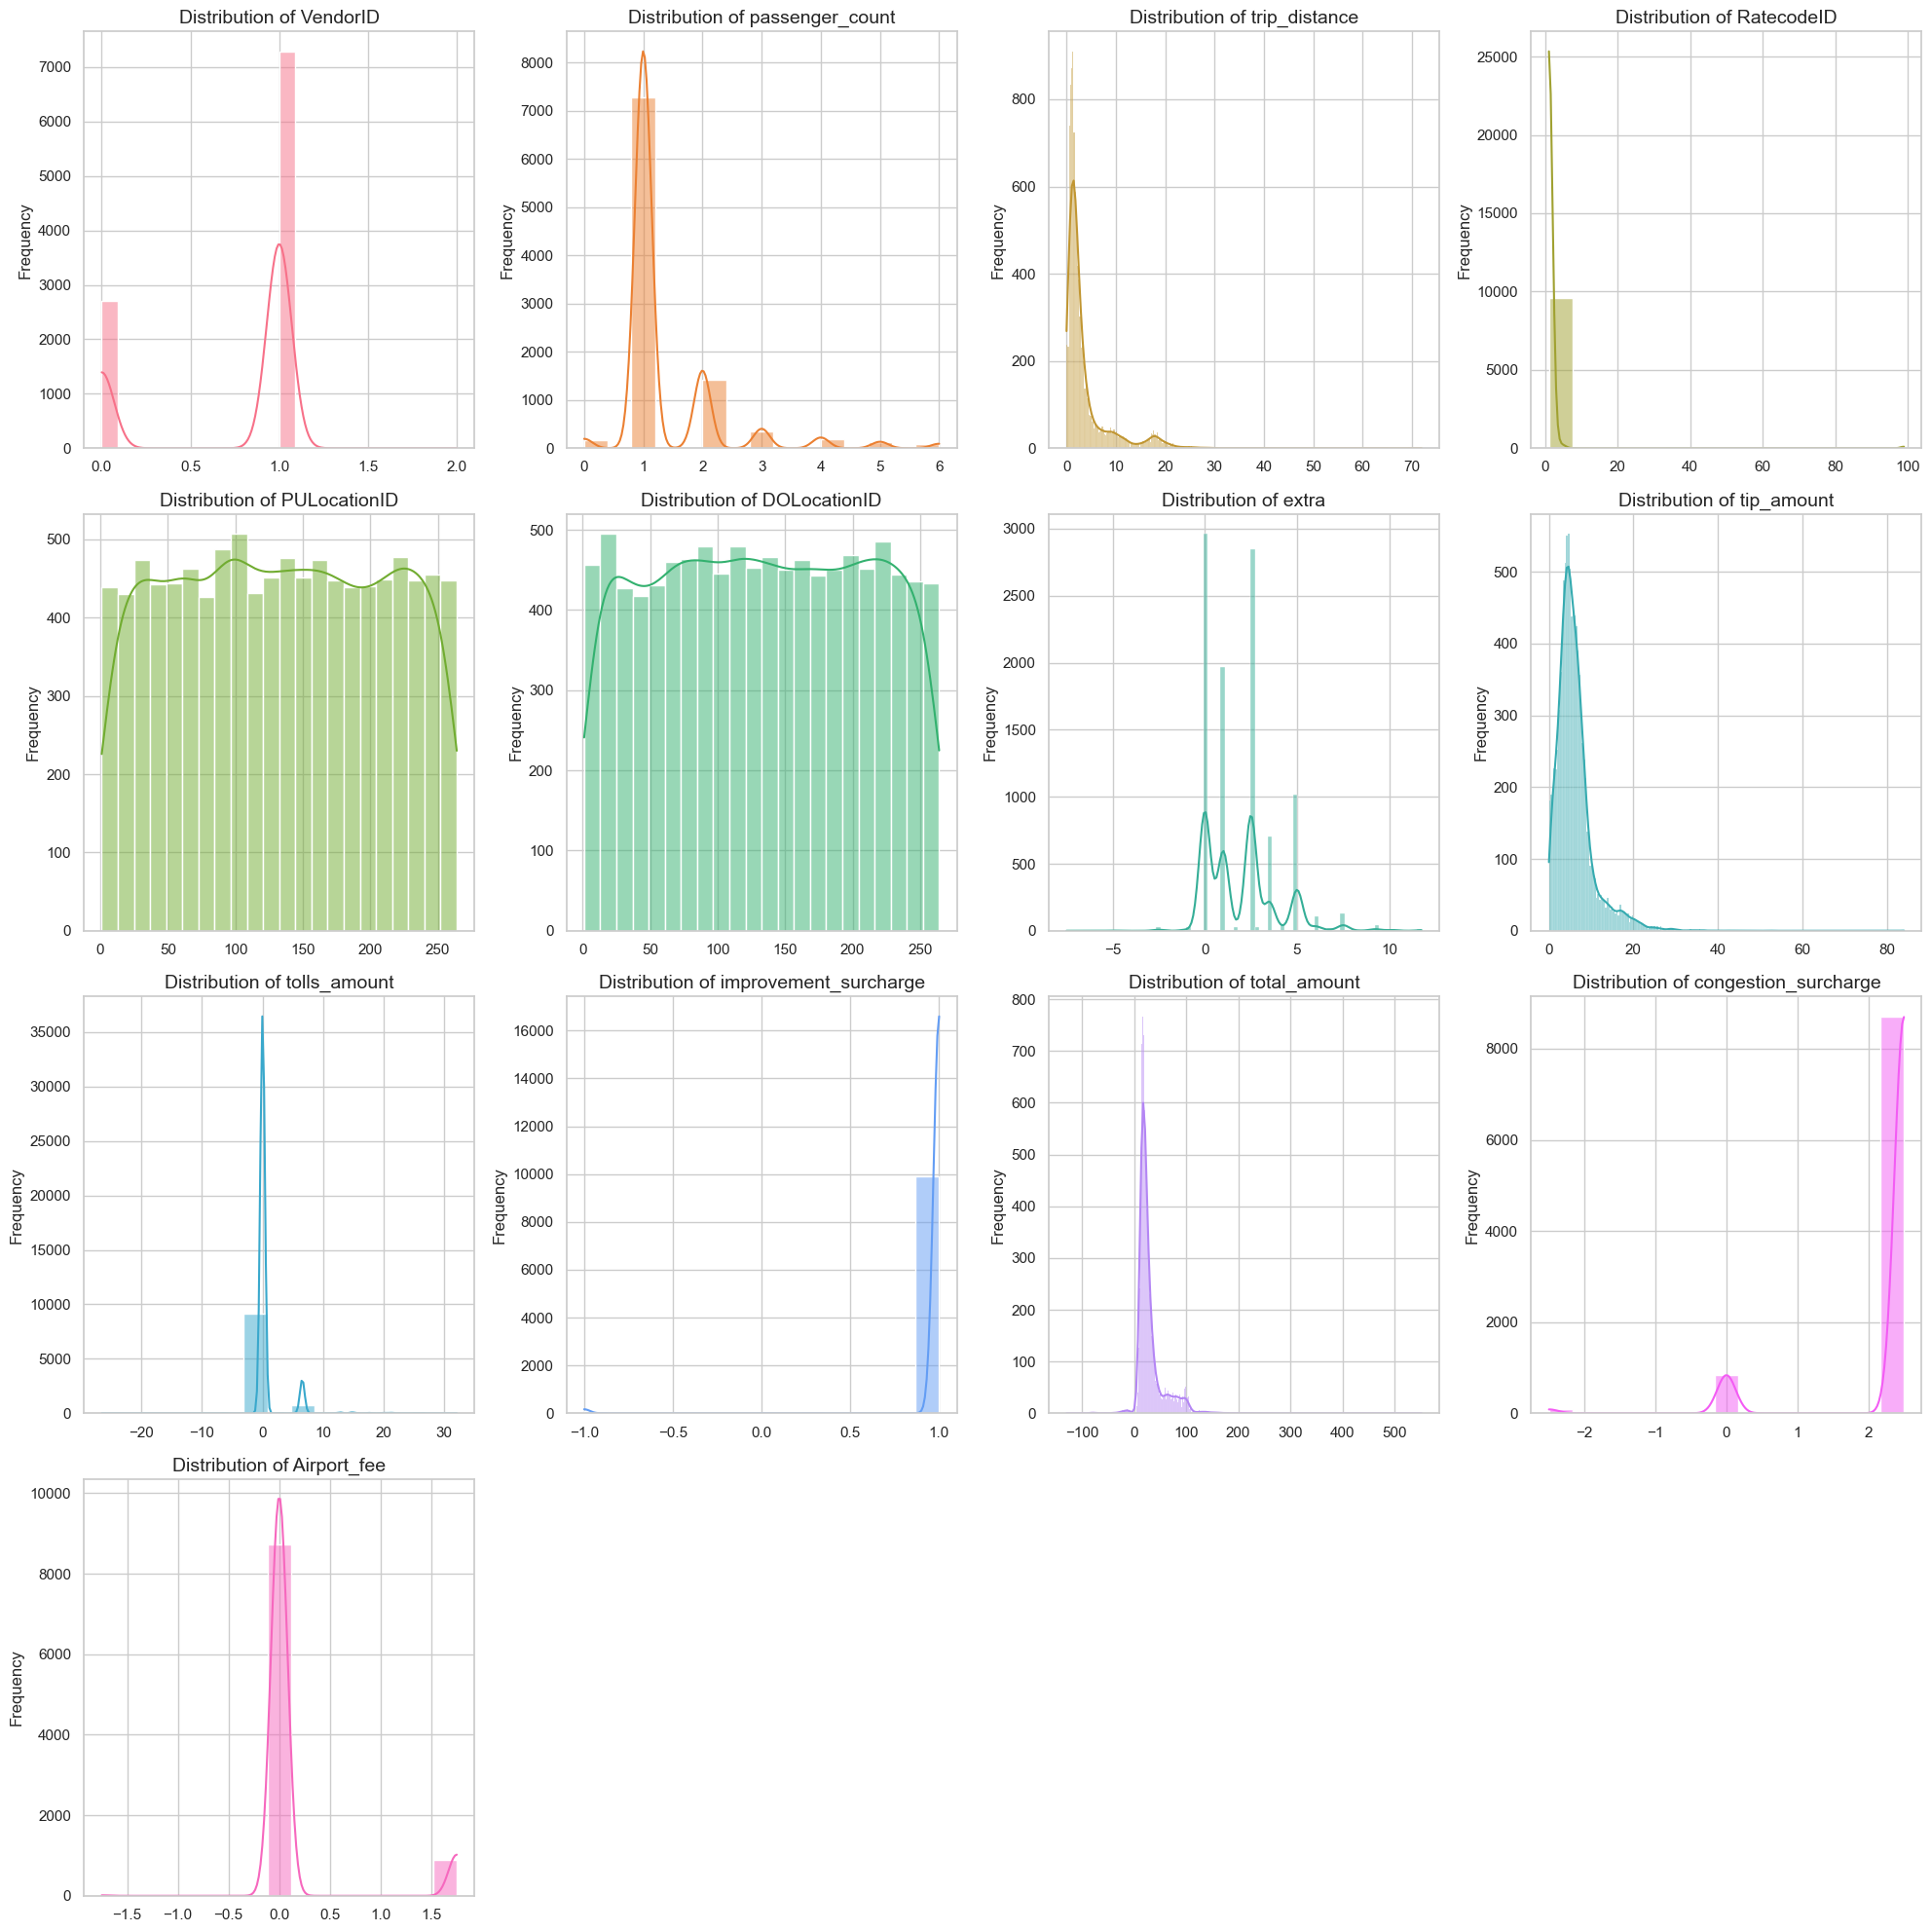

In [181]:
# Histograms for numerical features.
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

_ = plt.figure(figsize=(20, 5 * n_rows))
_ = sns.set_theme(style="whitegrid")

for i, col in enumerate(numerical_cols):
  _ = plt.subplot(n_rows, n_cols, i + 1)
  _ = sns.histplot(train[col], kde=True, color=sns.color_palette("husl", len(numerical_cols))[i])
  _ = plt.title(f"Distribution of {col}", fontsize=14)
  _ = plt.xlabel("")
  _ = plt.ylabel("Frequency")

plt.tight_layout()

## Categorical and Temporal Column Analysis

### Temporal Features

In [182]:
# Processing temporal columns for train and test sets.

for df in [train, test]:
  # Convert to datetime
  df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
  df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

  # Engineer trip duration
  df['trip_duration'] = (df['tpep_dropoff_datetime'] -
                         df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

  # Extract hour and day
  df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
  df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

print("Row counts for each hour of the day (Train):")
hour_counts = train['pickup_hour'].value_counts().sort_index().reset_index()
hour_counts.columns = ['Hour', 'Row Count']
display(hour_counts)

print("Row counts for each day of the week (Train):")
day_counts = train['pickup_day'].value_counts().reset_index()
day_counts.columns = ['Day of Week', 'Row Count']
display(day_counts)

Row counts for each hour of the day (Train):


,Hour,Row Count
0,0,262
1,1,145
2,2,83
3,3,68
4,4,63
5,5,74
6,6,148
7,7,226
8,8,301
9,9,343


Row counts for each day of the week (Train):


,Day of Week,Row Count
0,Thursday,4167
1,Friday,3866
2,Wednesday,1928
3,Saturday,39


Plotting hour and day of week frequencies.


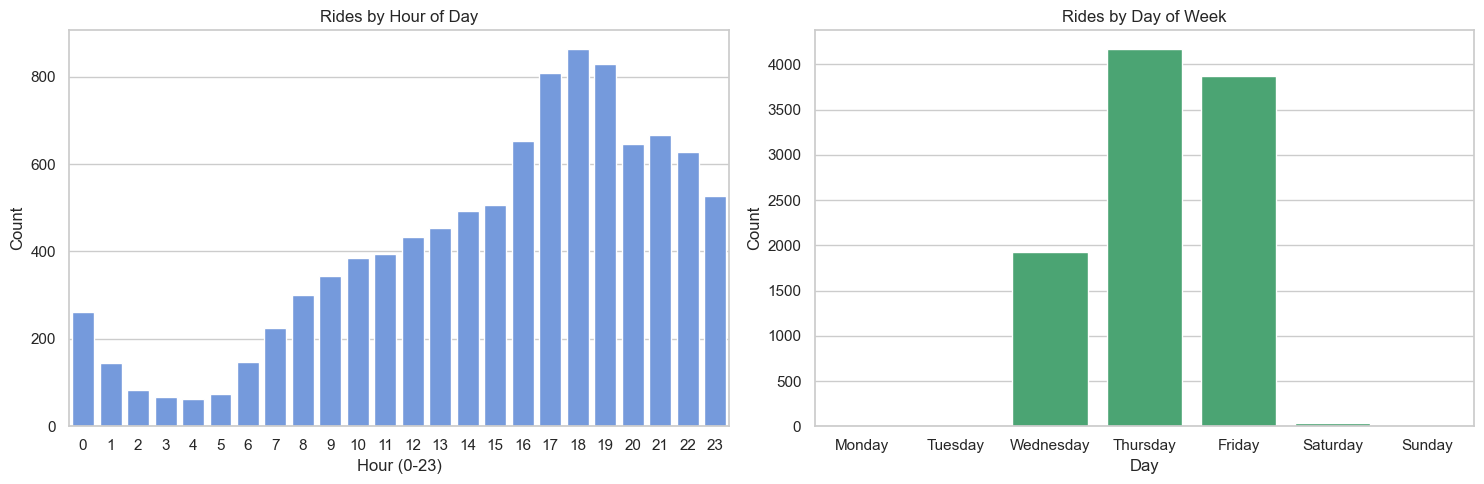

In [183]:
print("Plotting hour and day of week frequencies.")
_ = plt.figure(figsize=(15, 5))
_ = sns.set_theme(style="whitegrid")

_ = plt.subplot(1, 2, 1)
_ = sns.countplot(x='pickup_hour', data=train, color='cornflowerblue')
_ = plt.title("Rides by Hour of Day")
_ = plt.xlabel("Hour (0-23)")
_ = plt.ylabel("Count")

_ = plt.subplot(1, 2, 2)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
_ = sns.countplot(x='pickup_day', data=train, order=days_order, color='mediumseagreen')
_ = plt.title("Rides by Day of Week")
_ = plt.xlabel("Day")
_ = plt.ylabel("Count")

plt.tight_layout()

### Other Categorical Features

In [184]:
print("Row counts for store_and_fwd_flag:")
flag_counts = train['store_and_fwd_flag'].value_counts().reset_index()
flag_counts.columns = ['Store and Fwd Flag', 'Row Count']
display(flag_counts)

print("Row counts for payment_type:")
payment_counts = train['payment_type'].value_counts().reset_index()
payment_counts.columns = ['Payment Type', 'Row Count']
display(payment_counts)

Row counts for store_and_fwd_flag:


,Store and Fwd Flag,Row Count
0,N,9565
1,Y,69


Row counts for payment_type:


,Payment Type,Row Count
0,Credit Card,7727
1,Cash,1706
2,Wallet,366
3,unknown,133
4,UPI,68


Plotting categorical feature distributions.


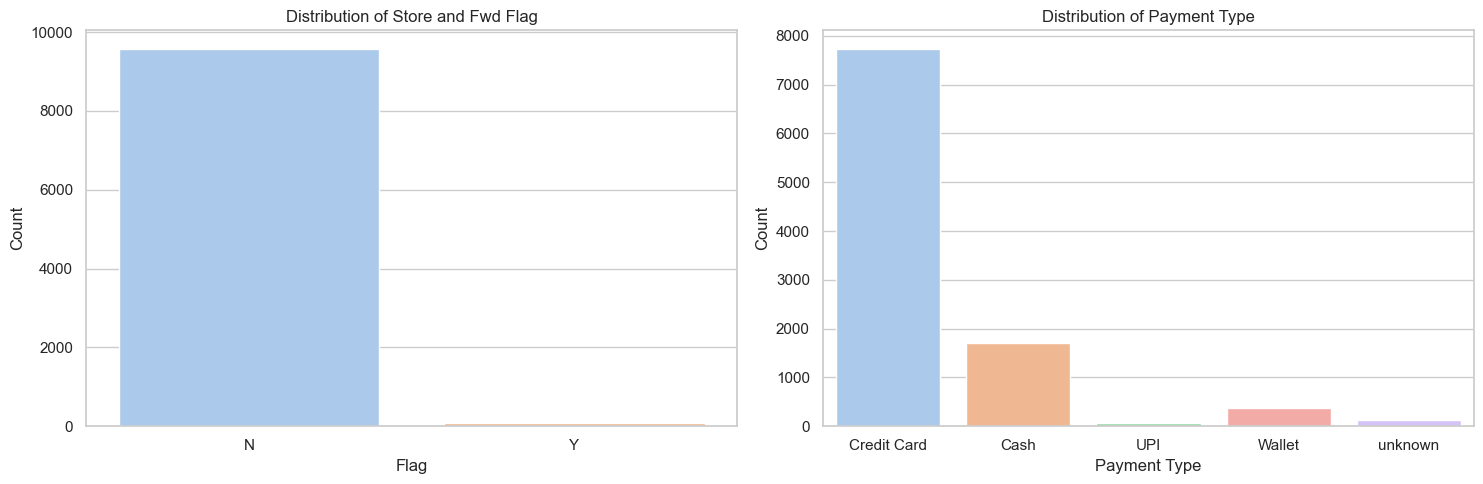

In [185]:
print("Plotting categorical feature distributions.")
_ = plt.figure(figsize=(15, 5))

_ = plt.subplot(1, 2, 1)
_ = sns.countplot(
    x='store_and_fwd_flag',
    hue='store_and_fwd_flag',
    data=train,
    palette='pastel',
    legend=False
)
_ = plt.title("Distribution of Store and Fwd Flag")
_ = plt.xlabel("Flag")
_ = plt.ylabel("Count")

_ = plt.subplot(1, 2, 2)
_ = sns.countplot(
    x='payment_type',
    hue='payment_type',
    data=train,
    palette='pastel',
    legend=False
)
_ = plt.title("Distribution of Payment Type")
_ = plt.xlabel("Payment Type")
_ = plt.ylabel("Count")

plt.tight_layout()

## Identify and Handle Missing Values

### Identify Missing Values

In [186]:
print("Missing values report for numerical columns:")
num_missing = train[numerical_cols].isnull().sum()
num_pct = (num_missing / len(train)) * 100
num_report = pd.DataFrame({
    'Missing Count': num_missing,
    'Percentage (%)': num_pct
})
display(num_report.sort_values(by='Missing Count', ascending=False))

Missing values report for numerical columns:


,Missing Count,Percentage (%)
passenger_count,366,3.66
RatecodeID,366,3.66
congestion_surcharge,366,3.66
Airport_fee,366,3.66
VendorID,0,0.00
PULocationID,0,0.00
trip_distance,0,0.00
DOLocationID,0,0.00
extra,0,0.00
tolls_amount,0,0.00


In [187]:
print("Missing values report for categorical columns:")
cat_missing = train[categorical_cols].isnull().sum()
cat_pct = (cat_missing / len(train)) * 100
cat_report = pd.DataFrame({
    'Missing Count': cat_missing,
    'Percentage (%)': cat_pct
})
display(cat_report.sort_values(by='Missing Count', ascending=False))

Missing values report for categorical columns:


,Missing Count,Percentage (%)
store_and_fwd_flag,366,3.66
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
payment_type,0,0.00


### Handle Missing Values

In [188]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [189]:
# Imputing numerical features with median.
num_features = [col for col in numerical_cols if col != 'total_amount']
train[num_features] = num_imputer.fit_transform(train[num_features])
test[num_features] = num_imputer.transform(test[num_features])

# Imputing categorical features with most frequent.
train[categorical_cols] = cat_imputer.fit_transform(train[categorical_cols])
test[categorical_cols] = cat_imputer.transform(test[categorical_cols])

print("Total missing values in train after imputation:")
print(train.isnull().sum().sum())

print("Total missing values in test after imputation:")
print(test.isnull().sum().sum())

Total missing values in train after imputation:
0
Total missing values in test after imputation:
0


## Identify and Handle Duplicates

### Identify Duplicates

In [190]:
duplicates_count = train.duplicated().sum()
print("Number of duplicate rows found:")
print(duplicates_count)

Number of duplicate rows found:
0


### Drop Duplicates

In [191]:
if duplicates_count > 0:
  print("Dropping duplicate rows from train data.")
  train = train.drop_duplicates()

  print("New train data shape:")
  print(train.shape)
else:
  print("No duplicates to drop.")

No duplicates to drop.


## Identify and Handle Outliers

### Outlier Identification via Percentiles

In [192]:
# Calculating percentiles for numerical columns.
percentiles = [0, 0.5, 0.75, 0.90, 0.99, 1.0]
percentile_stats = train[numerical_cols].quantile(percentiles).T
percentile_stats.columns = [
    'Minimum', 'Median', '75th Percentile',
    '90th Percentile', '99th Percentile', 'Maximum'
]

print("Percentile statistics:")
display(percentile_stats)

Percentile statistics:


,Minimum,Median,75th Percentile,90th Percentile,99th Percentile,Maximum
VendorID,0.00,1.00,1.00,1.00,1.00,2.00
passenger_count,0.00,1.00,1.00,2.00,5.00,6.00
trip_distance,0.00,1.82,3.63,9.70,21.24,71.94
RatecodeID,1.00,1.00,1.00,1.00,4.00,99.00
PULocationID,1.00,133.00,198.00,237.00,262.00,264.00
DOLocationID,1.00,132.00,199.00,237.00,262.00,264.00
extra,-7.50,1.75,2.50,5.00,7.50,11.75
tip_amount,0.00,5.21,7.46,10.79,22.03,84.03
tolls_amount,-26.55,0.00,0.00,0.00,6.55,32.05
improvement_surcharge,-1.00,1.00,1.00,1.00,1.00,1.00


### Outlier Identification via Interquartile Range (IQR)

In [193]:
# Calculating IQR bounds and outlier counts.
outlier_info = []

for col in numerical_cols:
  q1 = train[col].quantile(0.25)
  q3 = train[col].quantile(0.75)
  iqr = q3 - q1

  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  outliers_mask = (train[col] < lower_bound) | (train[col] > upper_bound)
  outlier_count = outliers_mask.sum()
  outlier_pct = (outlier_count / len(train)) * 100

  outlier_info.append({
      'Feature': col,
      'Lower Bound': lower_bound,
      'Upper Bound': upper_bound,
      'Outlier Count': outlier_count,
      'Outlier Percentage (%)': outlier_pct
  })

outlier_df = pd.DataFrame(outlier_info).set_index('Feature')

print("IQR bounds and outlier statistics:")
display(outlier_df)

IQR bounds and outlier statistics:


,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
Feature,,,,
VendorID,-1.50,2.50,0,0.00
passenger_count,1.00,1.00,2352,23.52
trip_distance,-2.77,7.47,1354,13.54
RatecodeID,1.00,1.00,577,5.77
PULocationID,-129.50,394.50,0,0.00
DOLocationID,-128.50,395.50,0,0.00
extra,-3.75,6.25,242,2.42
tip_amount,-2.52,13.44,657,6.57
tolls_amount,0.00,0.00,884,8.84


### Outlier Visualization

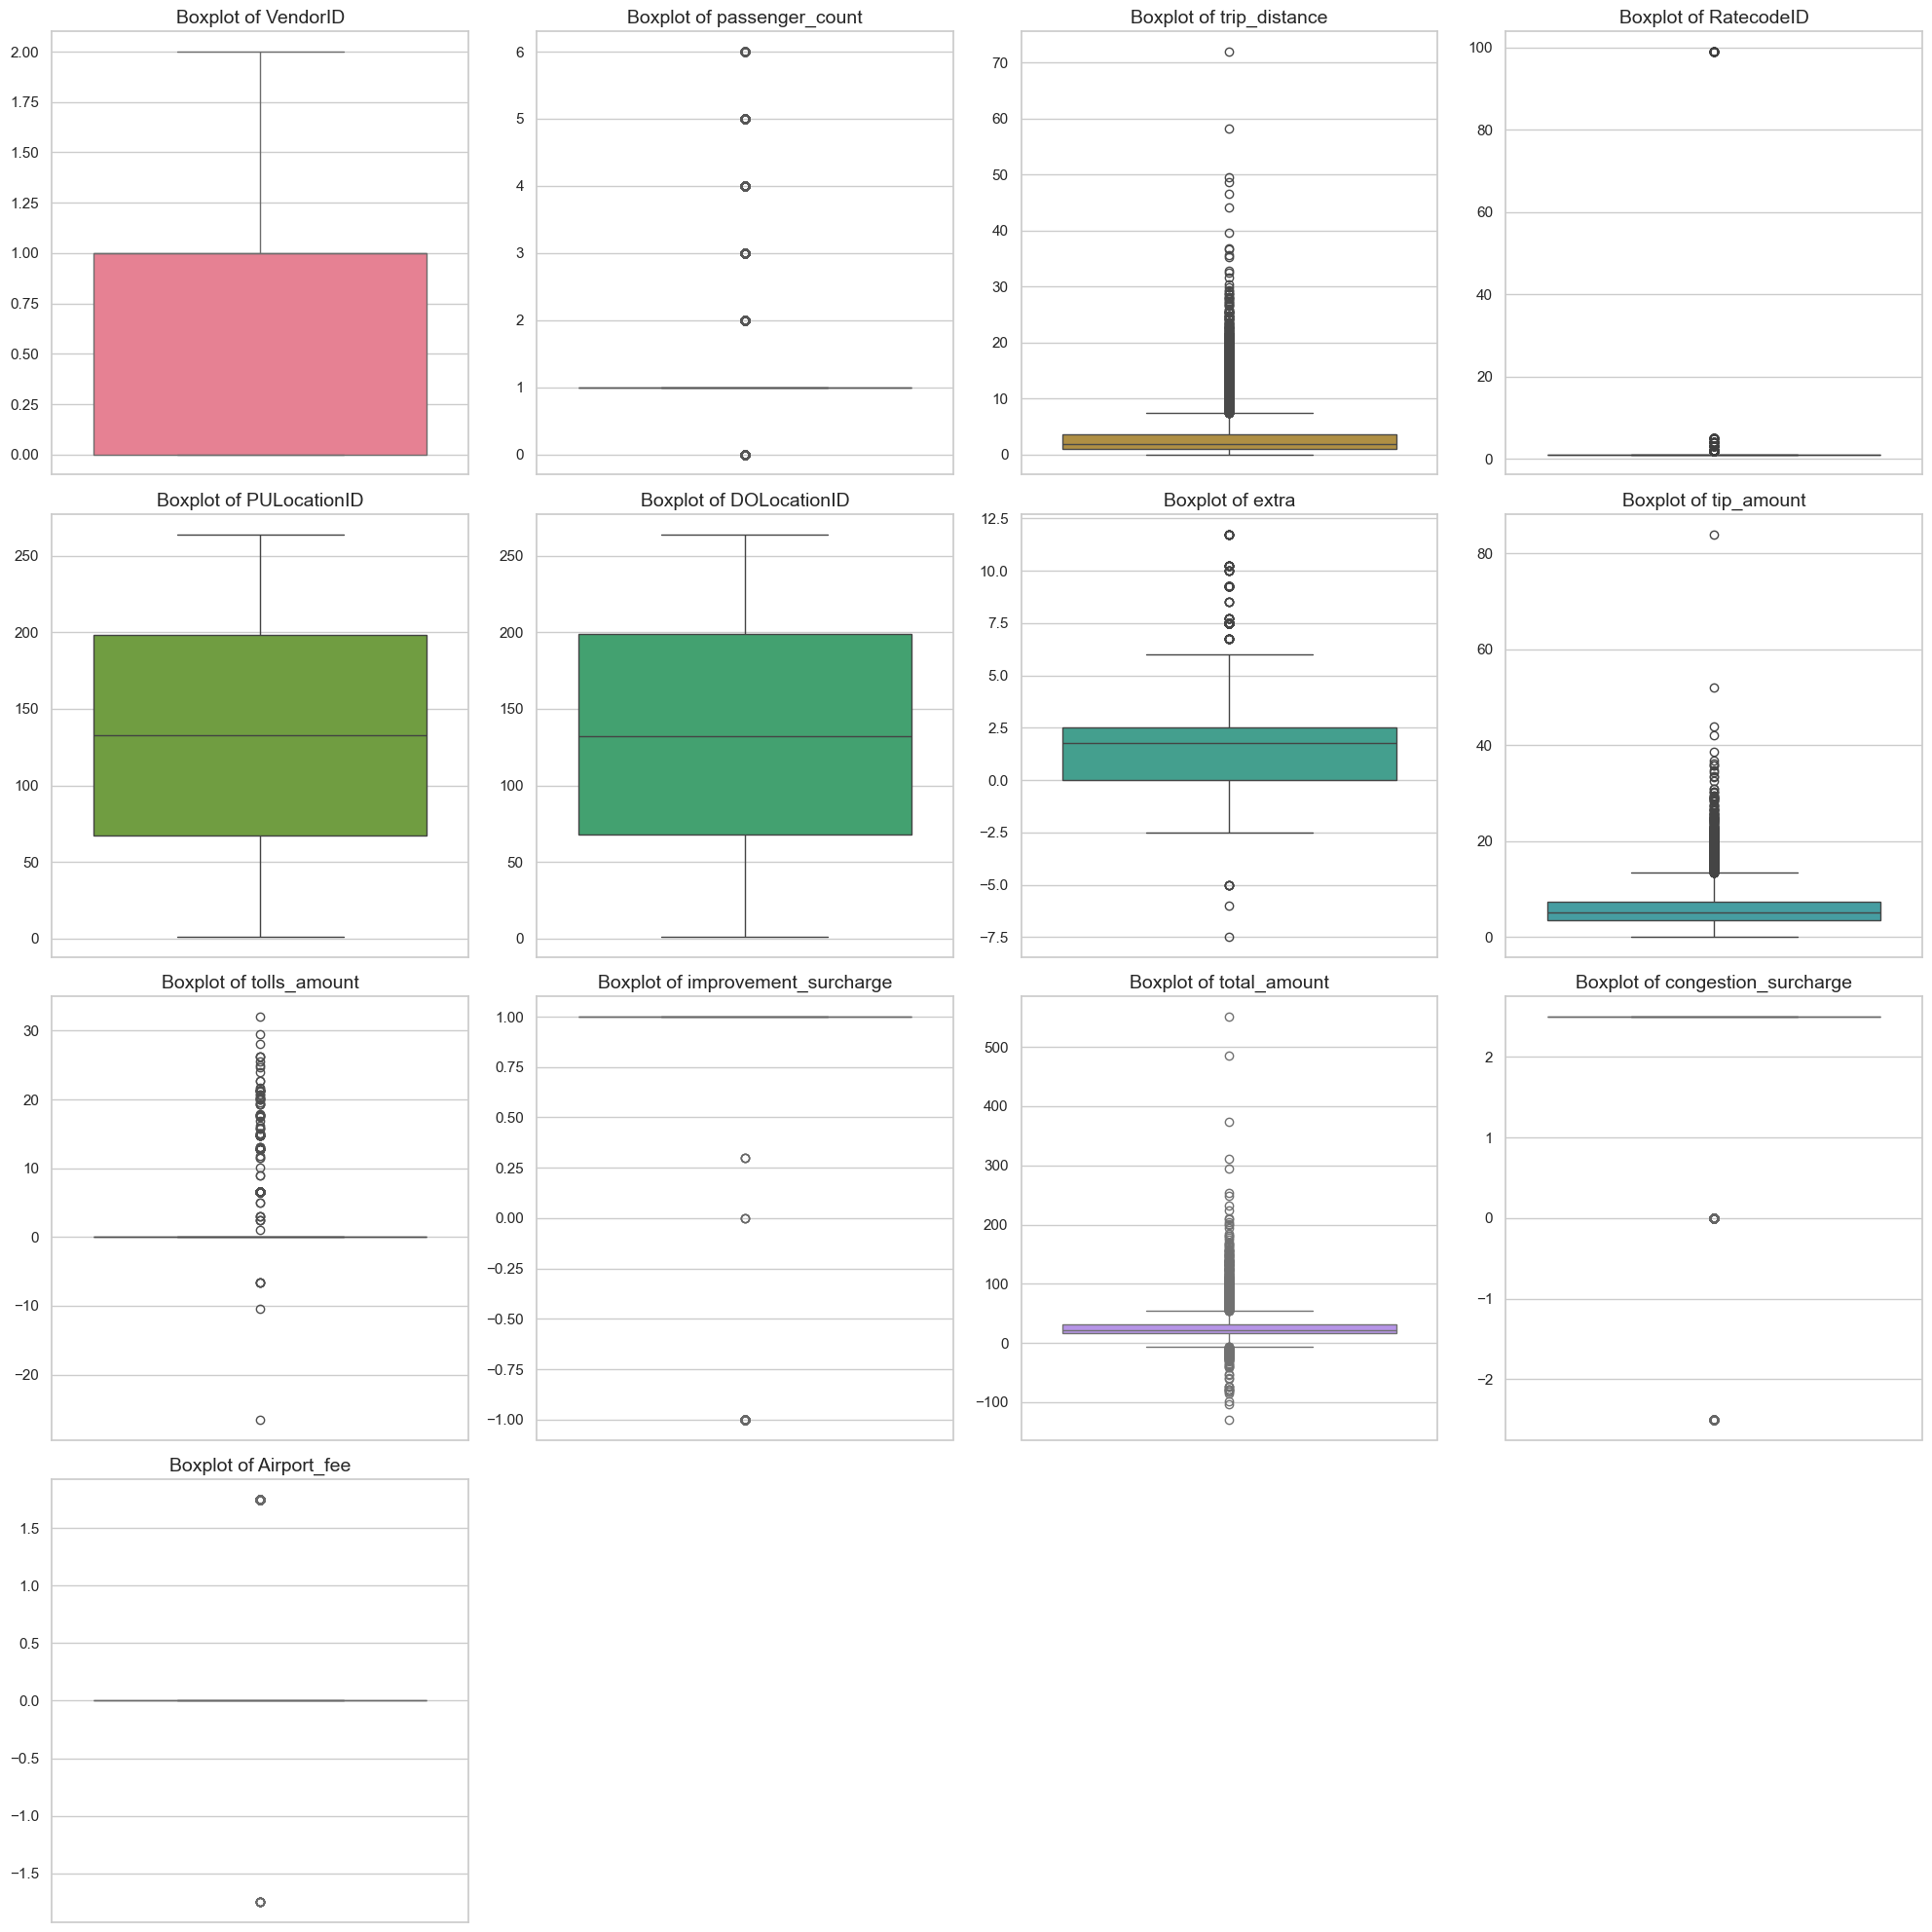

In [194]:
# Plotting box plots for numerical columns.
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

_ = plt.figure(figsize=(20, 5 * n_rows))
_ = sns.set_theme(style="whitegrid")

for i, col in enumerate(numerical_cols):
  _ = plt.subplot(n_rows, n_cols, i + 1)
  _ = sns.boxplot(y=train[col], color=sns.color_palette("husl", len(numerical_cols))[i])
  _ = plt.title(f"Boxplot of {col}", fontsize=14)
  _ = plt.ylabel("")

plt.tight_layout()

### Analyzing columns with negative values

In [195]:
# Count negative values per column
neg_counts = (train[numerical_cols] < 0).sum()
neg_cols = neg_counts[neg_counts > 0]
neg_pct = (neg_cols / len(train)) * 100

neg_report = pd.DataFrame({
    'Negative Count': neg_cols,
    'Percentage (%)': neg_pct
})

print("Columns containing negative values:")
display(neg_report.sort_values(by='Negative Count', ascending=False))

# Calculate overall rows lost if all negatives are dropped
neg_rows_mask = (train[numerical_cols] < 0).any(axis=1)
total_neg_rows = neg_rows_mask.sum()
total_neg_pct = (total_neg_rows / len(train)) * 100

print(f"Total rows with at least one negative value: {total_neg_rows}")
print(f"Percentage of training data to be lost: {total_neg_pct:.2f}%")

Columns containing negative values:


,Negative Count,Percentage (%)
total_amount,100,1.00
improvement_surcharge,100,1.00
congestion_surcharge,85,0.85
extra,57,0.57
Airport_fee,11,0.11
tolls_amount,6,0.06


Total rows with at least one negative value: 100
Percentage of training data to be lost: 1.00%


### RatecodeID Analysis

In [196]:
print("Unique values in RatecodeID:")
ratecode_uniques = train['RatecodeID'].unique()
print(sorted(ratecode_uniques))

Unique values in RatecodeID:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0)]


### Extreme High Values ( > 99th Percentile)

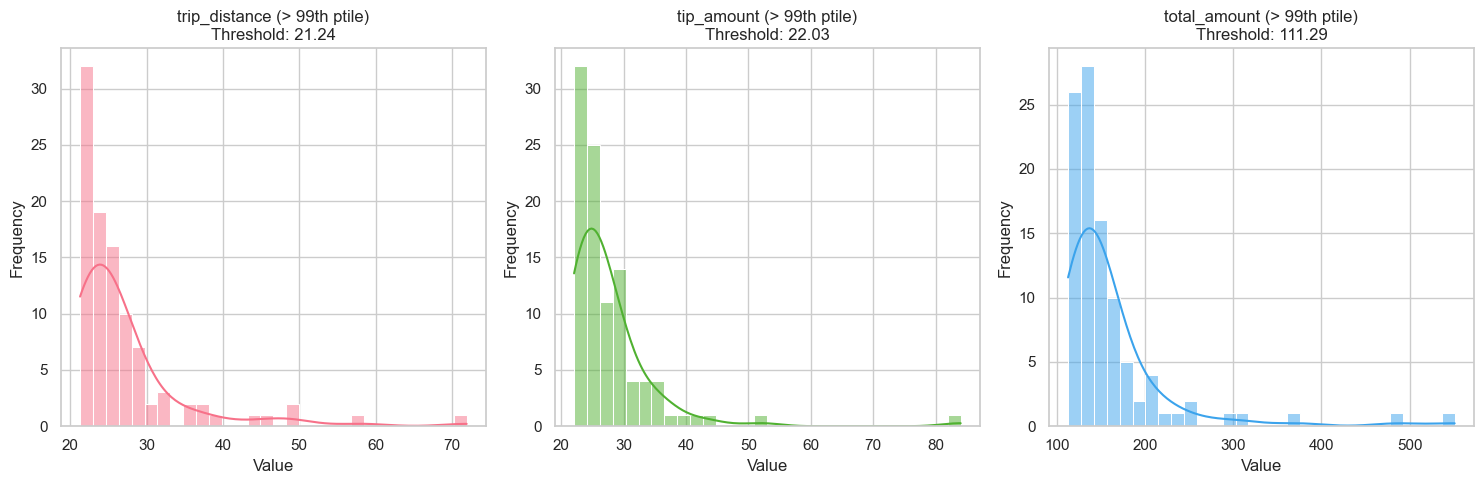

In [197]:
# Plotting distributions for values above the 99th percentile.
cols_to_plot = ['trip_distance', 'tip_amount', 'total_amount']

_ = plt.figure(figsize=(15, 5))
_ = sns.set_theme(style="whitegrid")

for i, col in enumerate(cols_to_plot):
  _ = plt.subplot(1, 3, i + 1)

  # Calculate 99th percentile threshold
  threshold = train[col].quantile(0.99)

  # Filter data above the threshold
  extreme_data = train[train[col] > threshold][col]

  _ = sns.histplot(extreme_data, bins=30, kde=True, color=sns.color_palette("husl", 3)[i])
  _ = plt.title(f"{col} (> 99th ptile)\nThreshold: {threshold:.2f}", fontsize=12)
  _ = plt.xlabel("Value")
  _ = plt.ylabel("Frequency")

plt.tight_layout()

### Outlier Handling Decisions

Based on the data exploration, the following decisions were made regarding outliers:

1. **Negative Values (Dropped):** Exactly 100 rows (about 1% of the training data) contained negative financial values (e.g., negative fares or surcharges). Since a taxi ride cannot have a negative cost in a valid predictive context, these are treated as anomalies or data entry errors and have been dropped.

2. **Anomalous RatecodeID (Dropped):** The `RatecodeID` column contained values of 99. Standard rate codes range from 1 to 6. Rows containing a `RatecodeID` greater than 6 were deemed anomalous and dropped.

3. **Extreme High Values (Configurable Clipping):** The columns `trip_distance`, `tip_amount`, and `total_amount` contained extreme upper-tail outliers. A configurable threshold (`CLIPPING_PERCENTILE`) is used to control clipping. If set below 1.0, values are clipped to that percentile, and boolean flags (`[col]_is_extreme`) are created to retain the knowledge of the extreme event. If set to 1.0, clipping is skipped entirely to allow the models to train on the raw distribution.

### Handling outliers based on finalized decisions

In [198]:
# 1. Drop rows with negative values in numerical columns (Train only)
train_before = train.shape[0]
train = train[~(train[numerical_cols] < 0).any(axis=1)]
print("Rows dropped due to negative values:", train_before - train.shape[0])

Rows dropped due to negative values: 100


In [199]:
# 2. Drop rows with anomalous RatecodeID (Train only)
train_before = train.shape[0]
train = train[train['RatecodeID'] <= 6]
print("Rows dropped due to anomalous RatecodeID:", train_before - train.shape[0])

Rows dropped due to anomalous RatecodeID: 36


In [200]:
# 3. Clip and flag extreme high values (Train and Test)
CLIPPING_PERCENTILE = 0.995

if CLIPPING_PERCENTILE < 1.0:
  print(f"Clipping extreme values at {CLIPPING_PERCENTILE * 100}th percentile.")
  cols_to_clip = ['trip_distance', 'tip_amount', 'total_amount']

  for col in cols_to_clip:
    # Calculate the threshold using the training data
    threshold = train[col].quantile(CLIPPING_PERCENTILE)
    print(f"{CLIPPING_PERCENTILE * 100}th percentile for {col}: {threshold:.2f}")

    # Process train data
    train[f'{col}_is_extreme'] = train[col] > threshold
    train[col] = train[col].clip(upper=threshold)

    # Process test data if the column exists (total_amount is not in test)
    if col in test.columns:
      test[f'{col}_is_extreme'] = test[col] > threshold
      test[col] = test[col].clip(upper=threshold)
else:
  print("CLIPPING_PERCENTILE is 1.0. Skipping clipping entirely.")

Clipping extreme values at 99.5th percentile.
99.5th percentile for trip_distance: 24.55
99.5th percentile for tip_amount: 25.53
99.5th percentile for total_amount: 139.27


In [201]:
# print("Applying 1.5 IQR outlier removal on training data...")

# # cols_to_iqr = ['trip_distance', 'tip_amount', 'total_amount']
# cols_to_iqr = ['trip_distance']

# train_before_iqr = train.shape[0]

# for col in cols_to_iqr:
#   Q1 = train[col].quantile(0.25)
#   Q3 = train[col].quantile(0.75)
#   IQR = Q3 - Q1

#   lower_bound = Q1 - 1.5 * IQR
#   upper_bound = Q3 + 1.5 * IQR

#   # Keep only the rows within the IQR bounds
#   train = train[(train[col] >= lower_bound) & (train[col] <= upper_bound)]

# print(f"Rows dropped due to IQR: {train_before_iqr - train.shape[0]}")
# print("New train shape:", train.shape)

In [202]:
print("Outlier handling complete.")
print("New train data shape:")
print(train.shape)
print("New test data shape:")
print(test.shape)

Outlier handling complete.
New train data shape:
(9864, 23)
New test data shape:
(1500, 22)


## Bivariate Analysis

In [203]:
# Only exclude the location IDs
id_columns = ['PULocationID', 'DOLocationID']

# Filter numerical columns (excluding IDs and the target variable)
features_to_plot = [
    col for col in numerical_cols if col not in id_columns and col != 'total_amount'
]

# Add the temporal features, engineered duration, and remaining categorical flags
features_to_plot.extend([
    'trip_duration',
    'pickup_hour',
    'pickup_day',
    'store_and_fwd_flag',
    'payment_type'
])

print("Features selected for bivariate analysis:")
print(features_to_plot)

Features selected for bivariate analysis:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration', 'pickup_hour', 'pickup_day', 'store_and_fwd_flag', 'payment_type']


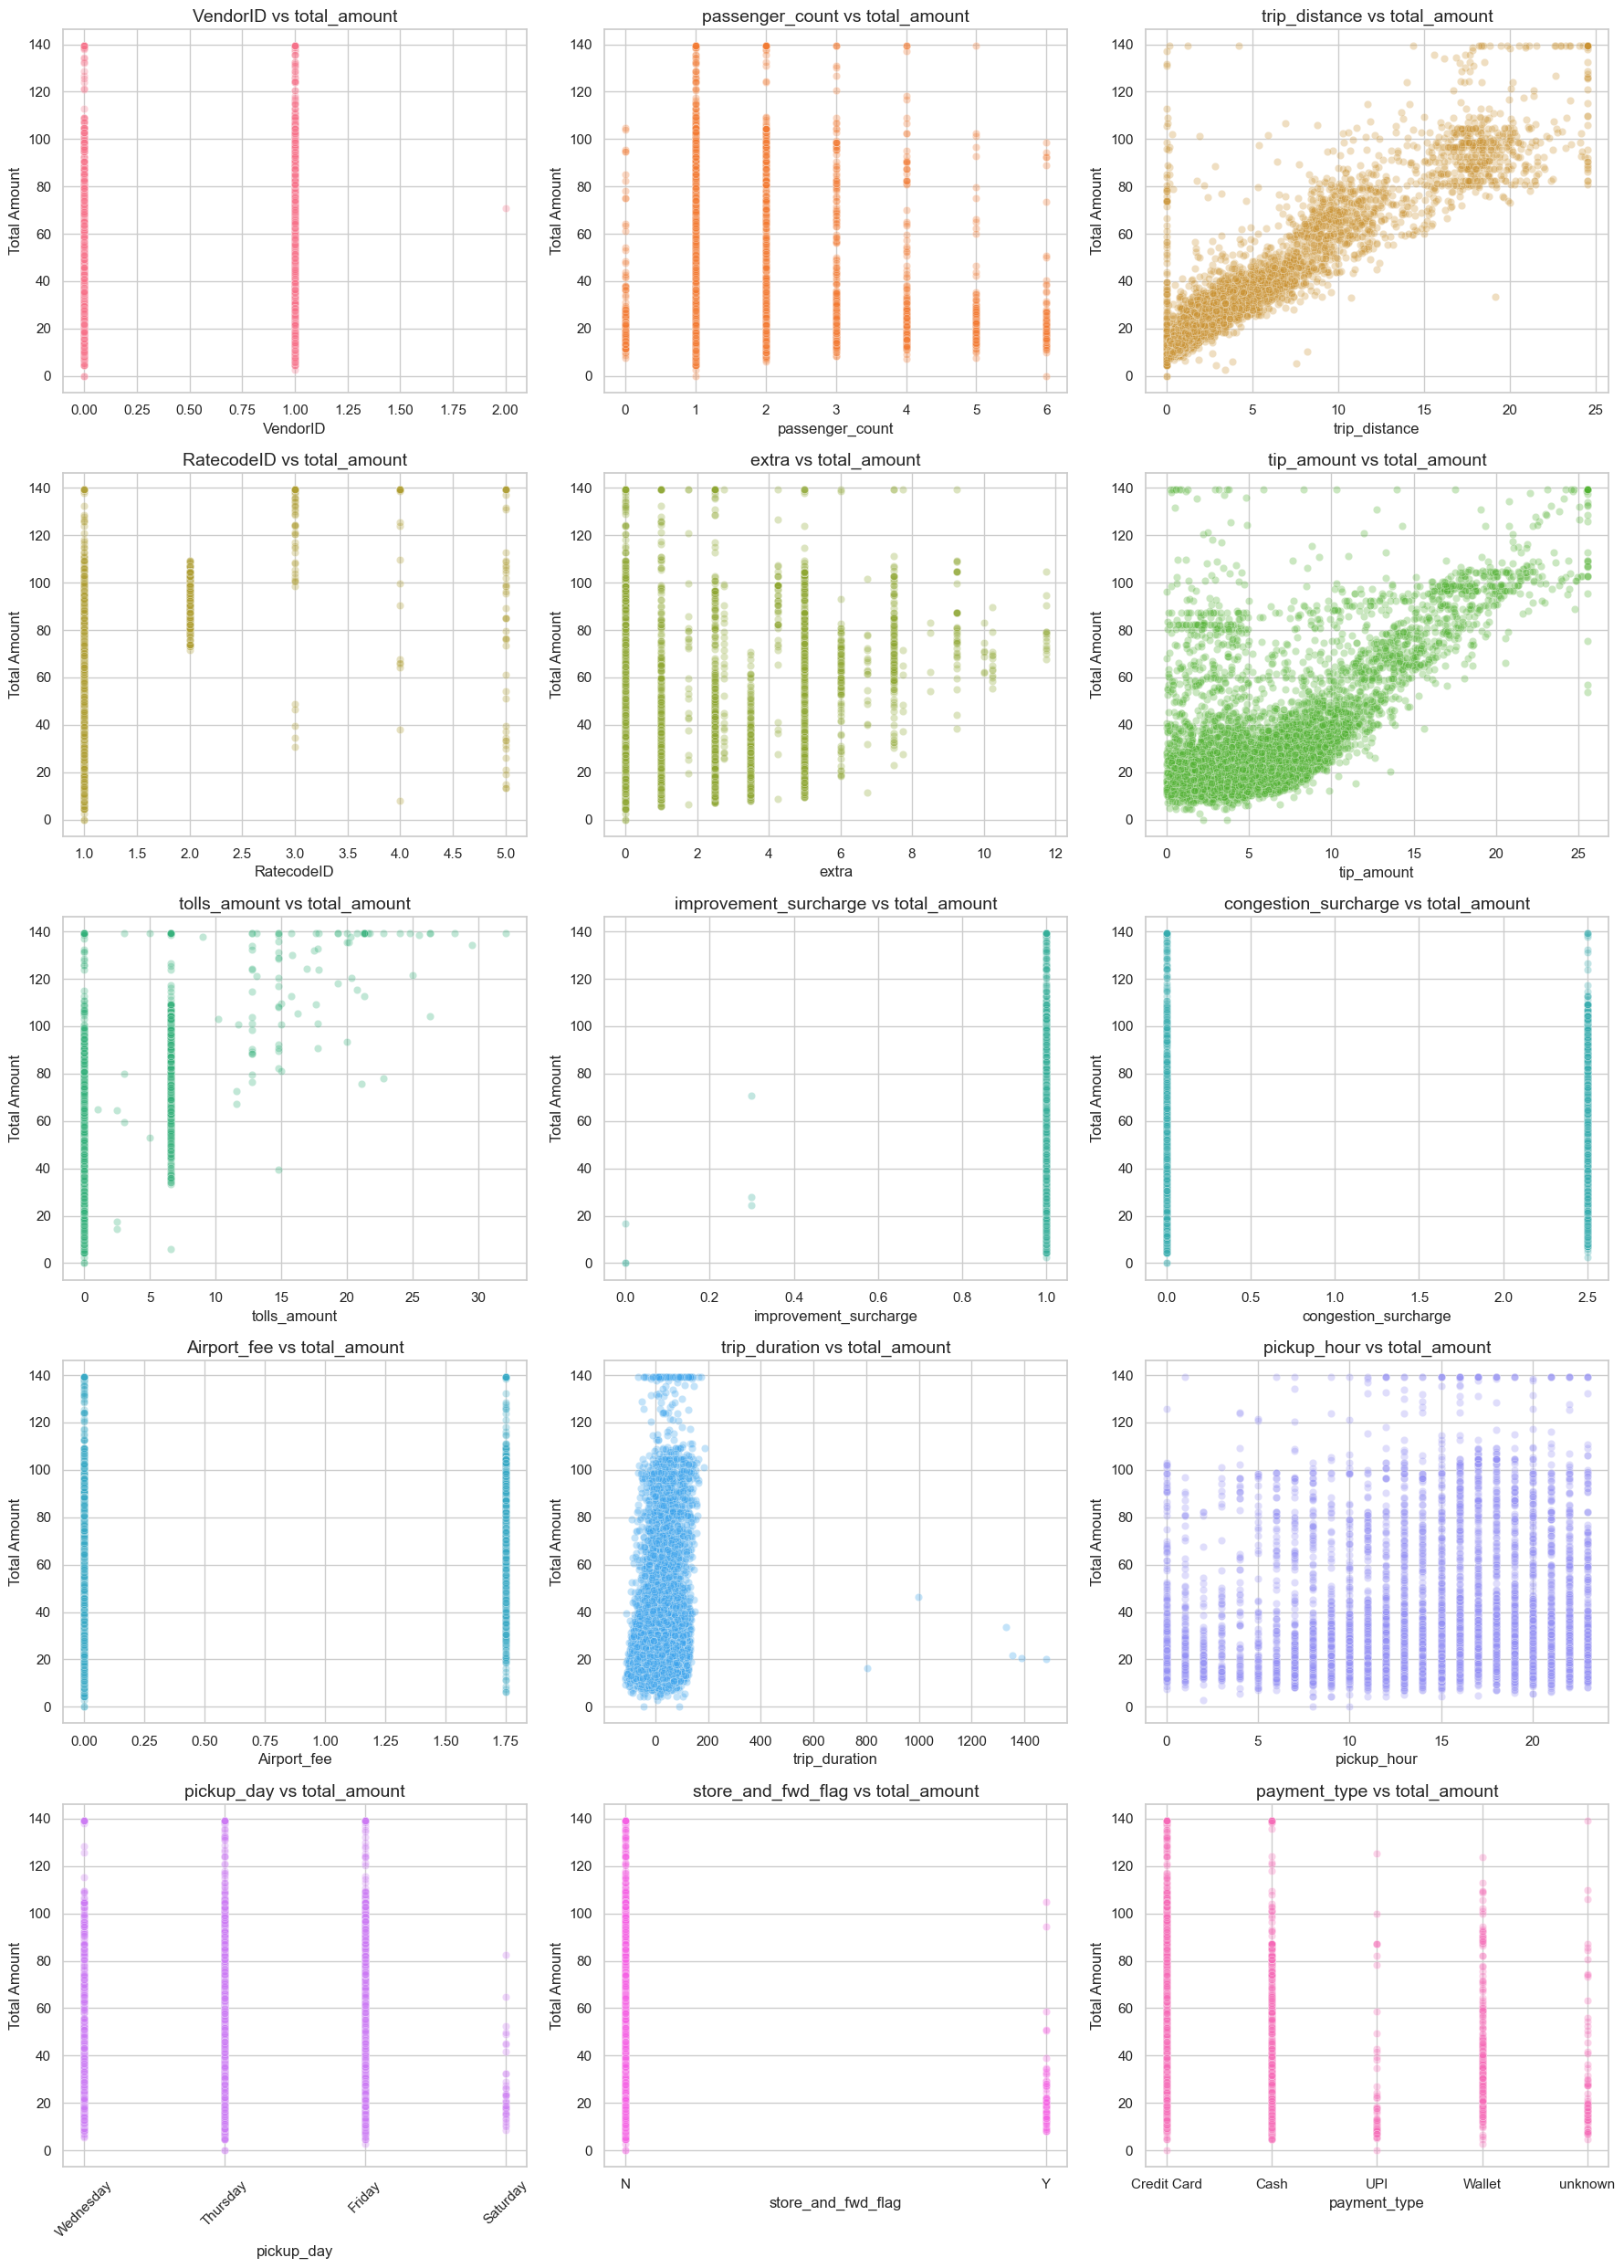

In [204]:
# Set up the plot grid
n_cols = 3
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

_ = plt.figure(figsize=(18, 5 * n_rows))
_ = sns.set_theme(style="whitegrid")

for i, col in enumerate(features_to_plot):
  _ = plt.subplot(n_rows, n_cols, i + 1)

  # Scatter plot with alpha for density visibility
  _ = sns.scatterplot(
      x=train[col],
      y=train['total_amount'],
      alpha=0.3,
      color=sns.color_palette("husl", len(features_to_plot))[i]
  )

  _ = plt.title(f"{col} vs total_amount", fontsize=14)
  _ = plt.ylabel("Total Amount")
  _ = plt.xlabel(col)

  # Rotate x-labels for categorical/temporal columns for better readability
  if col == 'pickup_day':
    _ = plt.xticks(rotation=45)

plt.tight_layout()

### Insights from Bivariate Analysis

1. **Trip Distance vs. Total Amount:** There is a highly visible, strong positive linear correlation between `trip_distance` and `total_amount`. As the distance increases, the fare increases proportionally. We can also likely observe a base fare (where distance is near 0 but total amount is still around $3-$5) and potentially some flat-rate trips (horizontal lines of points at specific fare amounts, like standard airport rates).

2. **Tip Amount vs. Total Amount:**
   `tip_amount` shows a strong positive relationship with `total_amount`. This is expected because the tip is directly added to the total amount, and passengers often tip a percentage of the base fare, causing the tip to scale linearly with the total cost of the ride.

3. **Temporal Features (Hour & Day) vs. Total Amount:**
   The scatter plots for `pickup_hour` and `pickup_day` show dense vertical bands. While rides happen at all hours and days, the density and the upper bounds of `total_amount` might shift. For instance, peak hours or specific days (like weekends) might show a higher concentration of expensive rides (longer trips or higher congestion/time surcharges).

# Preprocessing

In [205]:
# Dropping datetime columns, Location IDs, and unmatched columns.

# Define specific columns to drop for train and test
cols_to_drop_train = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'PULocationID', 'DOLocationID', 'total_amount_is_extreme'
]

cols_to_drop_test = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'PULocationID', 'DOLocationID', 'id'
]

train = train.drop(columns=cols_to_drop_train, errors='ignore')
test = test.drop(columns=cols_to_drop_test, errors='ignore')

print("Columns dropped successfully.")

Columns dropped successfully.


In [206]:
# Converting VendorID and RatecodeID to strings for categorical encoding.
# This ensures they are treated as categories, not numbers
train['VendorID'] = train['VendorID'].astype(str)
train['RatecodeID'] = train['RatecodeID'].astype(str)

test['VendorID'] = test['VendorID'].astype(str)
test['RatecodeID'] = test['RatecodeID'].astype(str)

In [207]:
print("Current Train Data Preview:")
col_mid = train.shape[1] // 2

print("Part 1 (First half of columns):")
display(train.iloc[:, :col_mid].head())

print("Part 2 (Remaining columns):")
display(train.iloc[:, col_mid:].head())

Current Train Data Preview:
Part 1 (First half of columns):


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,extra,tip_amount,tolls_amount
0,0.0,1.00,1.50,1.0,N,Credit Card,5.00,6.53,0.00
1,0.0,1.00,3.80,1.0,N,Credit Card,5.00,9.19,0.00
2,1.0,2.00,1.89,1.0,N,Credit Card,2.50,6.79,0.00
3,1.0,1.00,1.10,1.0,N,Credit Card,1.00,3.70,0.00
4,1.0,2.00,2.84,1.0,N,Credit Card,2.50,7.84,0.00


Part 2 (Remaining columns):


,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration,pickup_hour,pickup_day,trip_distance_is_extreme,tip_amount_is_extreme
0,1.00,24.80,2.50,0.00,50.43,17,Wednesday,False,False
1,1.00,31.55,2.50,0.00,-8.40,19,Thursday,False,False
2,1.00,24.84,2.50,0.00,-27.52,18,Friday,False,False
3,1.00,13.45,2.50,0.00,-2.05,22,Friday,False,False
4,1.00,29.88,2.50,0.00,-67.78,18,Wednesday,False,False


## Feature and Target Separation

In [208]:
X_train = train.drop(columns=['total_amount'])
y_train = train['total_amount']
X_test = test.copy()

## Final Data Sanity Check

In [209]:
print("Final Sanity Check")
print("-" * 20)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nX_test columns:")
print(X_test.columns.tolist())

print("\nChecking column alignment...")

if list(X_train.columns) == list(X_test.columns):
  print("SUCCESS: X_train and X_test columns match perfectly in order and names.")
else:
  print("WARNING: X_train and X_test columns do not match!")
  print("Missing in X_test:", set(X_train.columns) - set(X_test.columns))
  print("Missing in X_train:", set(X_test.columns) - set(X_train.columns))

Final Sanity Check
--------------------
X_train shape: (9864, 17)
y_train shape: (9864,)
X_test shape: (1500, 17)

X_train columns:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration', 'pickup_hour', 'pickup_day', 'trip_distance_is_extreme', 'tip_amount_is_extreme']

X_test columns:
['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'payment_type', 'extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'trip_duration', 'pickup_hour', 'pickup_day', 'trip_distance_is_extreme', 'tip_amount_is_extreme']

Checking column alignment...
SUCCESS: X_train and X_test columns match perfectly in order and names.


## Validation Split

In [210]:
# Splitting training data into train and validation sets (90/10).
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42
)

print("Final Data Shapes")
print("-" * 20)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)

Final Data Shapes
--------------------
X_train shape: (8877, 17)
y_train shape: (8877,)
X_val shape: (987, 17)
y_val shape: (987,)
X_test shape: (1500, 17)


## Scaling and Encoding

**Scaling (StandardScaler):** Numerical features like `trip_distance` and `trip_duration` have vastly different ranges. Scaling ensures that distance-based algorithms or gradient descent-based models do not get skewed by features with larger magnitudes. `StandardScaler` standardizes features by removing the mean and scaling to unit variance.


**Encoding (OneHotEncoder):** Categorical features like `VendorID`, `RatecodeID`, and `pickup_day` are nominal. Using label encoding would introduce a false ordinal relationship (e.g., implying Vendor 2 is "greater" than Vendor 1). `OneHotEncoder` creates binary columns for each category, preventing this issue. We set `handle_unknown='ignore'` to safely handle any unexpected categories in the validation or test sets.

In [211]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [212]:
print("Defining numerical and categorical feature lists.")
# Extract feature lists directly from X_train to ensure perfect alignment
num_features = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_features = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

print("Numerical features:", len(num_features))
print("Categorical features:", len(cat_features))

Defining numerical and categorical feature lists.
Numerical features: 12
Categorical features: 5


In [213]:
print("Creating preprocessing pipelines.")
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# sparse_output=False keeps the data dense, making it easier to convert back to dataframes if needed
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Creating preprocessing pipelines.


In [214]:
print("Combining pipelines into a ColumnTransformer.")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='passthrough'
)

Combining pipelines into a ColumnTransformer.


In [215]:
print("Fitting and transforming data.")
# Fit ONLY on the training data to prevent data leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Final Transformed Data Shapes")
print("-" * 20)
print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

Fitting and transforming data.
Final Transformed Data Shapes
--------------------
X_train_processed shape: (8877, 31)
X_val_processed shape: (987, 31)
X_test_processed shape: (1500, 31)


# Model Building

In [216]:
# Initialize a dictionary to store the R2 scores of all models
model_performances = {}

## Linear Regression

In [217]:
from sklearn.linear_model import LinearRegression

print("Training Linear Regression.")
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

lr_preds = lr.predict(X_val_processed)
lr_r2 = r2_score(y_val, lr_preds)

print("Linear Regression R2 Score:", lr_r2)
model_performances['Linear Regression'] = lr_r2

Training Linear Regression.


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Linear Regression R2 Score: 0.9312596903736308


## Ridge Regression

In [218]:
from sklearn.linear_model import Ridge

print("Training Ridge Regression.")
ridge = Ridge(random_state=42)
ridge.fit(X_train_processed, y_train)

ridge_preds = ridge.predict(X_val_processed)
ridge_r2 = r2_score(y_val, ridge_preds)

print("Ridge Regression R2 Score:", ridge_r2)
model_performances['Ridge Regression'] = ridge_r2

Training Ridge Regression.


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


Ridge Regression R2 Score: 0.9311721535202206


## Lasso Regression

In [219]:
from sklearn.linear_model import Lasso

print("Training Lasso Regression.")
lasso = Lasso(random_state=42)
lasso.fit(X_train_processed, y_train)

lasso_preds = lasso.predict(X_val_processed)
lasso_r2 = r2_score(y_val, lasso_preds)

print("Lasso Regression R2 Score:", lasso_r2)
model_performances['Lasso Regression'] = lasso_r2

Training Lasso Regression.


,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


Lasso Regression R2 Score: 0.8994581389882093


## ElasticNet Regression

In [220]:
from sklearn.linear_model import ElasticNet

print("Training ElasticNet Regression.")
elastic = ElasticNet(random_state=42)
elastic.fit(X_train_processed, y_train)

elastic_preds = elastic.predict(X_val_processed)
elastic_r2 = r2_score(y_val, elastic_preds)

print("ElasticNet R2 Score:", elastic_r2)
model_performances['ElasticNet'] = elastic_r2

Training ElasticNet Regression.


,alpha,1.0
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


ElasticNet R2 Score: 0.8520625160577296


## Decision Tree Regressor

In [221]:
from sklearn.tree import DecisionTreeRegressor

print("Training Decision Tree.")
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_processed, y_train)

dt_preds = dt.predict(X_val_processed)
dt_r2 = r2_score(y_val, dt_preds)

print("Decision Tree R2 Score:", dt_r2)
model_performances['Decision Tree'] = dt_r2

Training Decision Tree.


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Decision Tree R2 Score: 0.9217671034073032


## Random Forest Regressor

In [222]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest.")
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train_processed, y_train)

rf_preds = rf.predict(X_val_processed)
rf_r2 = r2_score(y_val, rf_preds)

print("Random Forest R2 Score:", rf_r2)
model_performances['Random Forest'] = rf_r2

Training Random Forest.


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Random Forest R2 Score: 0.9522449011151181


## Gradient Boosting Regressor

In [223]:
from sklearn.ensemble import GradientBoostingRegressor

print("Training Gradient Boosting.")
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_processed, y_train)

gb_preds = gb.predict(X_val_processed)
gb_r2 = r2_score(y_val, gb_preds)

print("Gradient Boosting R2 Score:", gb_r2)
model_performances['Gradient Boosting'] = gb_r2

Training Gradient Boosting.


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Gradient Boosting R2 Score: 0.9543287744735275


## AdaBoost Regressor

In [224]:
from sklearn.ensemble import AdaBoostRegressor

print("Training AdaBoost.")
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train_processed, y_train)

ada_preds = ada.predict(X_val_processed)
ada_r2 = r2_score(y_val, ada_preds)

print("AdaBoost R2 Score:", ada_r2)
model_performances['AdaBoost'] = ada_r2

Training AdaBoost.


,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,42


AdaBoost R2 Score: 0.8415203091200588


## K-Neighbors Regressor

In [225]:
from sklearn.neighbors import KNeighborsRegressor

print("Training K-Neighbors Regressor.")
knn = KNeighborsRegressor()
knn.fit(X_train_processed, y_train)

knn_preds = knn.predict(X_val_processed)
knn_r2 = r2_score(y_val, knn_preds)

print("K-Neighbors R2 Score:", knn_r2)
model_performances['K-Neighbors'] = knn_r2

Training K-Neighbors Regressor.


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


K-Neighbors R2 Score: 0.8986302661454966


## Support Vector Regressor (SVR)

In [226]:
from sklearn.svm import SVR

print("Training Support Vector Regressor.")
svr = SVR()
svr.fit(X_train_processed, y_train)

svr_preds = svr.predict(X_val_processed)
svr_r2 = r2_score(y_val, svr_preds)

print("SVR R2 Score:", svr_r2)
model_performances['SVR'] = svr_r2

Training Support Vector Regressor.


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


SVR R2 Score: 0.8401010597634676


## LightGBM Regressor

In [227]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [228]:
import lightgbm as lgb

print("Training LightGBM Regressor.")
lgbm = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # Suppresses the "No further splits" warning
)
lgbm.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_val_processed, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

lgbm_preds = lgbm.predict(X_val_processed)
lgbm_r2 = r2_score(y_val, lgbm_preds)

print("LightGBM R2 Score:", lgbm_r2)
model_performances['LightGBM'] = lgbm_r2

Training LightGBM Regressor.
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 25.7534
[200]	valid_0's l2: 25.0006
Early stopping, best iteration is:
[219]	valid_0's l2: 24.8807


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


LightGBM R2 Score: 0.9606051151519713


## Multi-Layer Perceptron (MLP) Regressor

In [229]:
from sklearn.neural_network import MLPRegressor

print("Training MLP Regressor.")
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train_processed, y_train)

mlp_preds = mlp.predict(X_val_processed)
mlp_r2 = r2_score(y_val, mlp_preds)

print("MLP Regressor R2 Score:", mlp_r2)
model_performances['MLP Regressor'] = mlp_r2

Training MLP Regressor.


,loss,'squared_error'
,hidden_layer_sizes,"(256, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True


MLP Regressor R2 Score: 0.9613687877658151


## Comparison of Model Performances

In [230]:
print("Comparing all model performances.")

# Convert the dictionary to a DataFrame for easy viewing
performance_df = pd.DataFrame(list(model_performances.items()),
                              columns=['Model', 'Validation R2 Score'])

# Sort the models from best to worst
performance_df = performance_df.sort_values(
    by='Validation R2 Score', ascending=False).reset_index(drop=True)

display(performance_df)

Comparing all model performances.


,Model,Validation R2 Score
0,MLP Regressor,0.96
1,LightGBM,0.96
2,Gradient Boosting,0.95
3,Random Forest,0.95
4,Linear Regression,0.93
5,Ridge Regression,0.93
6,Decision Tree,0.92
7,Lasso Regression,0.90
8,K-Neighbors,0.90
9,ElasticNet,0.85


## Hyperparameter Tuning

In [231]:
# Global dictionary to track the overall best model and individual results
best_tuned_models = {
    'overall_best_name': None,
    'overall_best_r2': -float('inf'),
    'overall_best_params': None,
    'model_results': {}
}


def update_global_best(model_name, best_r2, best_params):
  best_tuned_models['model_results'][model_name] = {'r2': best_r2, 'params': best_params}
  if best_r2 > best_tuned_models['overall_best_r2']:
    best_tuned_models['overall_best_r2'] = best_r2
    best_tuned_models['overall_best_name'] = model_name
    best_tuned_models['overall_best_params'] = best_params

## Ridge Regression

In [232]:
print("Tuning Ridge Regression...")
alphas = [0.1, 1.0, 10.0]
solvers = ['auto', 'saga']

best_ridge_r2 = -float('inf')
best_ridge_params = {}

for alpha in alphas:
  for solver in solvers:
    model = Ridge(alpha=alpha, solver=solver, random_state=42)
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_val_processed)
    r2 = r2_score(y_val, preds)

    if r2 > best_ridge_r2:
      best_ridge_r2 = r2
      best_ridge_params = {'alpha': alpha, 'solver': solver}

print(f"Best Ridge Parameters: {best_ridge_params}")
print(f"Best Ridge R2: {best_ridge_r2:.4f}")
update_global_best('Ridge', best_ridge_r2, best_ridge_params)

Tuning Ridge Regression...


,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'saga'
,positive,False
,random_state,42


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'saga'
,positive,False
,random_state,42


,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'saga'
,positive,False
,random_state,42


Best Ridge Parameters: {'alpha': 0.1, 'solver': 'auto'}
Best Ridge R2: 0.9313


In [233]:
print("Tuning Random Forest Regressor...")
n_estimators_list = [50, 100]
max_depths = [10, 20, None]

best_rf_r2 = -float('inf')
best_rf_params = {}

for n_est in n_estimators_list:
  for depth in max_depths:
    model = RandomForestRegressor(n_estimators=n_est, max_depth=depth, random_state=42, n_jobs=-1)
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_val_processed)
    r2 = r2_score(y_val, preds)

    if r2 > best_rf_r2:
      best_rf_r2 = r2
      best_rf_params = {'n_estimators': n_est, 'max_depth': depth}

print(f"Best Random Forest Parameters: {best_rf_params}")
print(f"Best Random Forest R2: {best_rf_r2:.4f}")
update_global_best('Random Forest', best_rf_r2, best_rf_params)

Tuning Random Forest Regressor...


,n_estimators,50
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,n_estimators,50
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Best Random Forest Parameters: {'n_estimators': 50, 'max_depth': 20}
Best Random Forest R2: 0.9540


## Gradient Boosting Regressor

In [234]:
print("Tuning Gradient Boosting Regressor...")
learning_rates = [0.05, 0.1]
n_estimators_list = [50, 100]
max_depths = [3, 5]

best_gb_r2 = -float('inf')
best_gb_params = {}

for lr in learning_rates:
  for n_est in n_estimators_list:
    for depth in max_depths:
      model = GradientBoostingRegressor(
          learning_rate=lr, n_estimators=n_est, max_depth=depth, random_state=42)
      model.fit(X_train_processed, y_train)
      preds = model.predict(X_val_processed)
      r2 = r2_score(y_val, preds)

      if r2 > best_gb_r2:
        best_gb_r2 = r2
        best_gb_params = {'learning_rate': lr, 'n_estimators': n_est, 'max_depth': depth}

print(f"Best Gradient Boosting Parameters: {best_gb_params}")
print(f"Best Gradient Boosting R2: {best_gb_r2:.4f}")
update_global_best('Gradient Boosting', best_gb_r2, best_gb_params)

Tuning Gradient Boosting Regressor...


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 5}
Best Gradient Boosting R2: 0.9575


## LightGBM Regressor

In [235]:
print("Tuning LightGBM Regressor...")
learning_rates = [0.05, 0.1]
num_leaves_list = [31, 63]
max_depths = [5, 8]

best_lgbm_r2 = -float('inf')
best_lgbm_params = {}

for lr in learning_rates:
  for leaves in num_leaves_list:
    for depth in max_depths:
      model = lgb.LGBMRegressor(
          learning_rate=lr,
          num_leaves=leaves,
          max_depth=depth,
          random_state=42,
          n_jobs=-1,
          verbose=-1
      )
      model.fit(X_train_processed, y_train)
      preds = model.predict(X_val_processed)
      r2 = r2_score(y_val, preds)

      if r2 > best_lgbm_r2:
        best_lgbm_r2 = r2
        best_lgbm_params = {'learning_rate': lr, 'num_leaves': leaves, 'max_depth': depth}

print(f"Best LightGBM Parameters: {best_lgbm_params}")
print(f"Best LightGBM R2: {best_lgbm_r2:.4f}")
update_global_best('LightGBM', best_lgbm_r2, best_lgbm_params)

Tuning LightGBM Regressor...


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Best LightGBM Parameters: {'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': 8}
Best LightGBM R2: 0.9609


## MLP Regressor

In [236]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

print("Tuning MLP Regressor... (This may take a while)")
hidden_layers = [(64,), (128, 64)]
alphas = [0.0001, 0.01]

best_mlp_r2 = -float('inf')
best_mlp_params = {}

for layers in hidden_layers:
  for alpha in alphas:
    model = MLPRegressor(
        hidden_layer_sizes=layers,
        alpha=alpha,
        early_stopping=True,
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_val_processed)
    r2 = r2_score(y_val, preds)

    if r2 > best_mlp_r2:
      best_mlp_r2 = r2
      best_mlp_params = {'hidden_layer_sizes': layers, 'alpha': alpha}

print(f"Best MLP Parameters: {best_mlp_params}")
print(f"Best MLP R2: {best_mlp_r2:.4f}")
update_global_best('MLP Regressor', best_mlp_r2, best_mlp_params)

Tuning MLP Regressor... (This may take a while)


,loss,'squared_error'
,hidden_layer_sizes,"(64,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


,loss,'squared_error'
,hidden_layer_sizes,"(64,)"
,activation,'relu'
,solver,'adam'
,alpha,0.01
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


,loss,'squared_error'
,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


,loss,'squared_error'
,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.01
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


Best MLP Parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}
Best MLP R2: 0.9622


## Final Comparison

In [237]:
print("\n--- Tuning Results Summary ---")
for model, data in best_tuned_models['model_results'].items():
  print(f"{model}: R2 = {data['r2']:.4f} | Params = {data['params']}")

print("\n🏆 OVERALL BEST MODEL 🏆")
print(f"Model: {best_tuned_models['overall_best_name']}")
print(f"R2 Score: {best_tuned_models['overall_best_r2']:.4f}")
print(f"Parameters: {best_tuned_models['overall_best_params']}")


--- Tuning Results Summary ---
Ridge: R2 = 0.9313 | Params = {'alpha': 0.1, 'solver': 'auto'}
Random Forest: R2 = 0.9540 | Params = {'n_estimators': 50, 'max_depth': 20}
Gradient Boosting: R2 = 0.9575 | Params = {'learning_rate': 0.1, 'n_estimators': 100, 'max_depth': 5}
LightGBM: R2 = 0.9609 | Params = {'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': 8}
MLP Regressor: R2 = 0.9622 | Params = {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}

🏆 OVERALL BEST MODEL 🏆
Model: MLP Regressor
R2 Score: 0.9622
Parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001}


# Making final submission

In [238]:
final_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    alpha=0.0001,
    early_stopping=True,
    max_iter=500,
    random_state=42
)

# final_model = LinearRegression()

In [239]:
# Fit the model on the training data
final_model.fit(X_train_processed, y_train)

print("Making predictions on the test set...")
test_predictions = final_model.predict(X_test_processed)

print("Generating Kaggle submission CSV...")
# Recreating the ID column (0 to 1499) and attaching predictions
submission = pd.DataFrame({
    'id': range(len(test_predictions)),
    'total_amount': test_predictions
})

# Save to CSV without the index column
submission_file = 'submission.csv'
submission.to_csv(submission_file, index=False)

print(f"Success! Predictions saved to '{submission_file}'.")
print("\nPreview of the submission file:")
display(submission.head())

,loss,'squared_error'
,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


Making predictions on the test set...
Generating Kaggle submission CSV...
Success! Predictions saved to 'submission.csv'.

Preview of the submission file:


,id,total_amount
0,0,15.50
1,1,27.21
2,2,25.52
3,3,19.91
4,4,13.58
